/opt/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== Descripción detallada de las 17 variables (16 features + target 'annual_premium') ===
             Variable                                                                                               Descripción                     Tipo
                  age    Edad del asegurado (años). Factor clave: mayores edades = mayor riesgo mortalidad → premios más altos.           Numérica (int)
               gender     Género (Male/Female). Las mujeres suelen tener mayor esperanza de vida → premios ligeramente menores.               Categórica
                  bmi   Índice de masa corporal (BMI). BMI alto indica obesidad → mayor riesgo de enfermedades → premios altos.         Numérica (float)
             children                  Número de hijos/dependientes. Puede influir en cobertura, pero indirectamente en riesgo.           Numérica (int)
      occupation_risk         Nivel de riesgo ocupacional (Low/Medium/High). Ocupaciones peligrosas aumentan riesgo mortalidad.       Categórica 

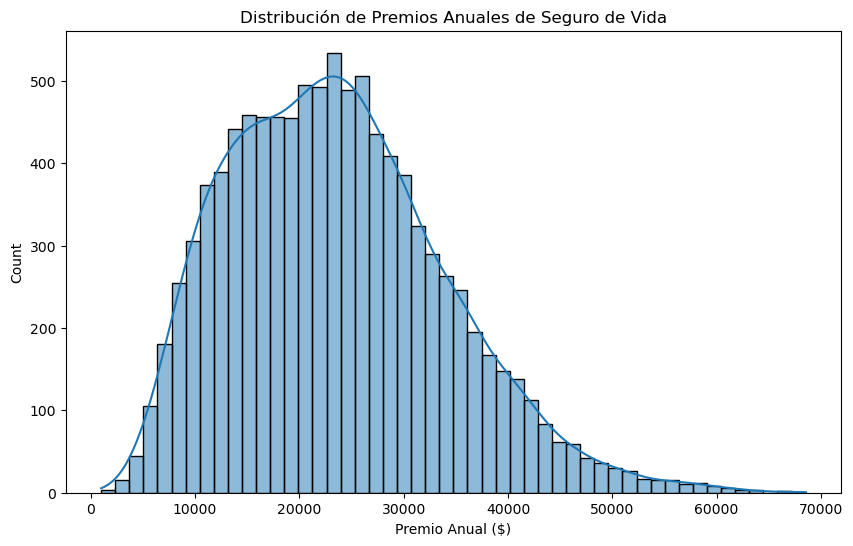

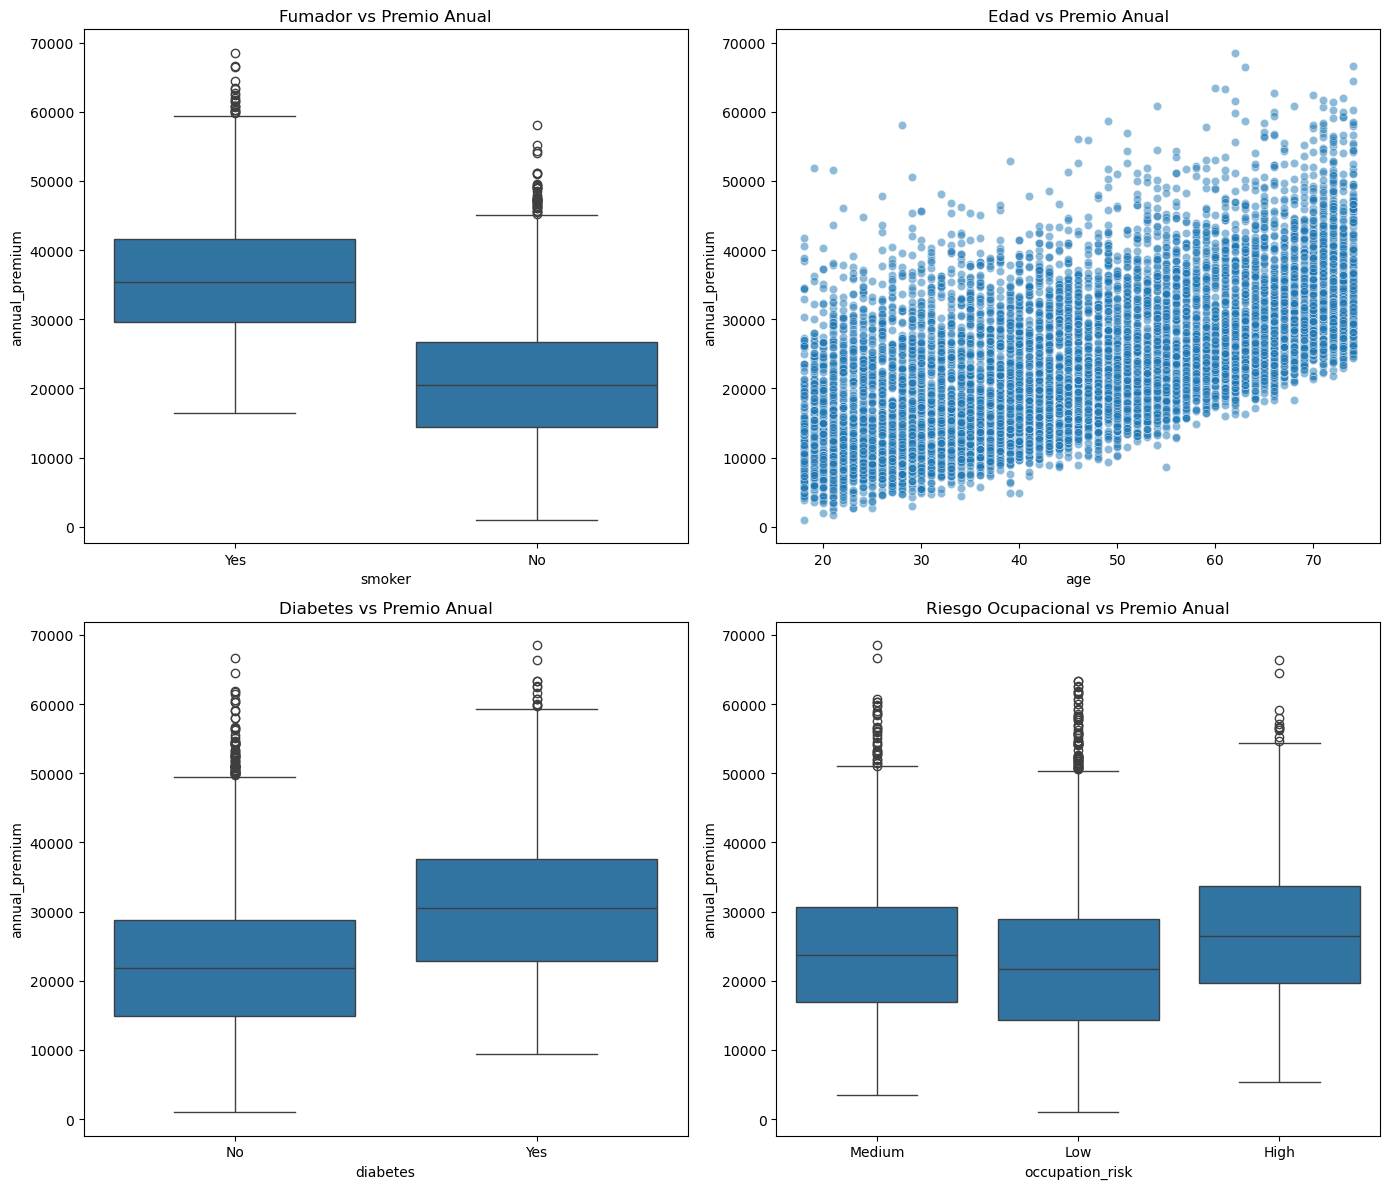

TypeError: AdaBoostRegressor.__init__() got an unexpected keyword argument 'base_estimator'

In [1]:
# =======================================================
# Ejemplo completo: Predicción de Premios/Costos de Seguros de Vida con AdaBoostRegressor
# Problema de REGRESIÓN: predecir 'annual_premium' (premio anual de seguro de vida en dólares)
# Dataset sintético profesional con 16 variables (demográficas + médicas) + target
# Incluye: Descripción de variables, EDA, entrenamiento, métricas, clasificación de riesgo (bajo/medio/alto),
# predicciones y análisis de sensibilidad con SHAP
# =======================================================
# Requisitos (instala si no los tienes):
# pip install pandas numpy scikit-learn matplotlib seaborn shap

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor  # Base estimator para AdaBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. Descripción detallada de las variables (significado profesional)
# =======================================================
# Creamos un DataFrame con el significado de cada variable para referencia clara
variable_descriptions = pd.DataFrame({
    'Variable': [
        'age', 'gender', 'bmi', 'children', 'occupation_risk', 
        'income_level', 'marital_status', 'education_level', 'region',
        'smoker', 'blood_pressure', 'cholesterol_level', 'diabetes',
        'heart_disease_history', 'cancer_family_history', 'exercise_frequency',
        'annual_premium'
    ],
    'Descripción': [
        'Edad del asegurado (años). Factor clave: mayores edades = mayor riesgo mortalidad → premios más altos.',
        'Género (Male/Female). Las mujeres suelen tener mayor esperanza de vida → premios ligeramente menores.',
        'Índice de masa corporal (BMI). BMI alto indica obesidad → mayor riesgo de enfermedades → premios altos.',
        'Número de hijos/dependientes. Puede influir en cobertura, pero indirectamente en riesgo.',
        'Nivel de riesgo ocupacional (Low/Medium/High). Ocupaciones peligrosas aumentan riesgo mortalidad.',
        'Nivel de ingresos (Low/Medium/High). Relacionado con capacidad de pago y estilo de vida.',
        'Estado civil (Single/Married/Divorced/Widowed). Casados suelen tener menor riesgo (estabilidad).',
        'Nivel educativo (High School/Bachelor/Master/PhD). Mayor educación correlaciona con mejor salud.',
        'Región geográfica (Northeast/Northwest/Southeast/Southwest). Diferencias en esperanza de vida por región.',
        'Fumador (Yes/No). Factor más fuerte: fumadores pagan 2-3x más por alto riesgo cáncer/pulmonar.',
        'Presión arterial (Normal/Elevated/High). Alta presión = mayor riesgo cardiovascular.',
        'Nivel de colesterol (mg/dL). Alto colesterol aumenta riesgo cardíaco.',
        'Diabetes (Yes/No). Enfermedad crónica que eleva significativamente el riesgo mortalidad.',
        'Historia de enfermedad cardíaca (Yes/No). Antecedentes familiares/personales = alto riesgo.',
        'Historia familiar de cáncer (Yes/No). Aumenta probabilidad de pólizas con exclusiones o premios altos.',
        'Frecuencia de ejercicio (None/Low/Medium/High). Mayor ejercicio = menor riesgo → premios menores.',
        'Premio anual del seguro de vida (target en dólares). Valor a predecir.'
    ],
    'Tipo': [
        'Numérica (int)', 'Categórica', 'Numérica (float)', 'Numérica (int)', 'Categórica ordinal',
        'Categórica ordinal', 'Categórica', 'Categórica ordinal', 'Categórica',
        'Binaria', 'Categórica ordinal', 'Numérica (int)', 'Binaria',
        'Binaria', 'Binaria', 'Categórica ordinal',
        'Numérica (float, target)'
    ]
})

print("=== Descripción detallada de las 17 variables (16 features + target 'annual_premium') ===")
print(variable_descriptions.to_string(index=False))

# =======================================================
# 2. Generación de dataset sintético profesional desde cero
# =======================================================
# Simulamos 10,000 asegurados con variables realistas para seguros de vida
# Premio anual generado con lógica actuarial (mayor riesgo = mayor premio)
np.random.seed(42)
n_samples = 10000

data = {
    # Demográficas
    'age': np.random.randint(18, 75, n_samples),  # Edad clave
    'gender': np.random.choice(['Male', 'Female'], n_samples, p=[0.52, 0.48]),
    'bmi': np.round(np.random.normal(27, 5, n_samples), 1).clip(16, 45),  # BMI realista
    'children': np.random.randint(0, 5, n_samples),
    'occupation_risk': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.6, 0.3, 0.1]),
    'income_level': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.4, 0.4, 0.2]),
    'marital_status': np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'], n_samples),
    'education_level': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples, p=[0.4, 0.3, 0.2, 0.1]),
    'region': np.random.choice(['Northeast', 'Northwest', 'Southeast', 'Southwest'], n_samples),
    
    # Médicas
    'smoker': np.random.choice(['Yes', 'No'], n_samples, p=[0.18, 0.82]),  # ~18% fumadores
    'blood_pressure': np.random.choice(['Normal', 'Elevated', 'High'], n_samples, p=[0.55, 0.3, 0.15]),
    'cholesterol_level': np.round(np.random.normal(200, 45, n_samples)).clip(120, 350).astype(int),
    'diabetes': np.random.choice(['Yes', 'No'], n_samples, p=[0.12, 0.88]),
    'heart_disease_history': np.random.choice(['Yes', 'No'], n_samples, p=[0.08, 0.92]),
    'cancer_family_history': np.random.choice(['Yes', 'No'], n_samples, p=[0.25, 0.75]),
    'exercise_frequency': np.random.choice(['None', 'Low', 'Medium', 'High'], n_samples, p=[0.25, 0.35, 0.3, 0.1])
}

df = pd.DataFrame(data)

# Generar 'annual_premium' con lógica actuarial realista
base_premium = 500
age_effect = df['age'] ** 1.8 * 10  # Efecto exponencial con edad
smoker_effect = (df['smoker'] == 'Yes') * 15000  # Fumadores pagan mucho más
bmi_effect = np.maximum(0, df['bmi'] - 25) * 300
diabetes_effect = (df['diabetes'] == 'Yes') * 8000
heart_effect = (df['heart_disease_history'] == 'Yes') * 12000
blood_pressure_effect = (df['blood_pressure'] == 'High') * 6000 + (df['blood_pressure'] == 'Elevated') * 2500
cholesterol_effect = np.maximum(0, df['cholesterol_level'] - 200) * 40
occupation_effect = (df['occupation_risk'] == 'High') * 5000 + (df['occupation_risk'] == 'Medium') * 2000
exercise_effect = - (df['exercise_frequency'] == 'High') * 3000 - (df['exercise_frequency'] == 'Medium') * 1500  # Negativo = reducción
cancer_effect = (df['cancer_family_history'] == 'Yes') * 4000

noise = np.random.normal(0, 1500, n_samples)
df['annual_premium'] = np.round(base_premium + age_effect + smoker_effect + bmi_effect + diabetes_effect +
                                heart_effect + blood_pressure_effect + cholesterol_effect +
                                occupation_effect + exercise_effect + cancer_effect + noise).clip(1000)

print(f"\nDataset creado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Rango de premios anuales: ${df['annual_premium'].min():,.0f} - ${df['annual_premium'].max():,.0f}")

# =======================================================
# 3. Exploratory Data Analysis (EDA)
# =======================================================
print("\n=== Descripción estadística general ===")
print(df.describe(include='all'))

# Distribución de premios
plt.figure(figsize=(10,6))
sns.histplot(df['annual_premium'], kde=True, bins=50)
plt.title('Distribución de Premios Anuales de Seguro de Vida')
plt.xlabel('Premio Anual ($)')
plt.show()

# Variables clave vs premio
fig, axes = plt.subplots(2, 2, figsize=(14,12))
sns.boxplot(x='smoker', y='annual_premium', data=df, ax=axes[0,0])
axes[0,0].set_title('Fumador vs Premio Anual')
sns.scatterplot(x='age', y='annual_premium', data=df, alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('Edad vs Premio Anual')
sns.boxplot(x='diabetes', y='annual_premium', data=df, ax=axes[1,0])
axes[1,0].set_title('Diabetes vs Premio Anual')
sns.boxplot(x='occupation_risk', y='annual_premium', data=df, ax=axes[1,1])
axes[1,1].set_title('Riesgo Ocupacional vs Premio Anual')
plt.tight_layout()
plt.show()

# =======================================================
# 4. Preprocesamiento
# =======================================================
# Codificar variables categóricas
cat_cols = df.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Separar features y target
X = df.drop('annual_premium', axis=1)
y = df['annual_premium']

# Escalar (útil aunque AdaBoost es basado en árboles)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# =======================================================
# 5. Entrenamiento del modelo AdaBoostRegressor
# =======================================================
base_estimator = DecisionTreeRegressor(max_depth=5)
model = AdaBoostRegressor(
    base_estimator=base_estimator,
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

# =======================================================
# 6. Predicciones y clasificación de riesgo
# =======================================================
y_pred = model.predict(X_test)

# Clasificación de riesgo basada en premio predicho
# Bajo: < $10,000 | Medio: $10,000 - $25,000 | Alto: > $25,000 (ajustable a contexto actuarial)
def classify_risk(premium):
    if premium < 10000:
        return 'Bajo'
    elif premium < 25000:
        return 'Medio'
    else:
        return 'Alto'

df_test = pd.DataFrame({'actual_premium': y_test, 'predicted_premium': y_pred})
df_test['risk_level'] = df_test['predicted_premium'].apply(classify_risk)

print("\n=== Ejemplos de clasificación de riesgo (primeros 10 casos) ===")
print(df_test[['actual_premium', 'predicted_premium', 'risk_level']].head(10))

print("\nDistribución de niveles de riesgo en test:")
print(df_test['risk_level'].value_counts(normalize=True) * 100)

# No hay "probabilidades" directas en regresión, pero podemos interpretar confianza vía error residual
# Aquí aproximamos "probabilidad de alto riesgo" como normalización del premio predicho
df_test['prob_high_risk'] = (df_test['predicted_premium'] - df_test['predicted_premium'].min()) / \
                            (df_test['predicted_premium'].max() - df_test['predicted_premium'].min())

print("\nEjemplo de 'probabilidad aproximada' de alto riesgo (normalizada 0-1):")
print(df_test[['predicted_premium', 'prob_high_risk', 'risk_level']].head(10))

# =======================================================
# 7. Métricas de evaluación completas (regresión)
# =======================================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Métricas del Modelo ===")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: {r2:.4f} (cuanto más cerca de 1, mejor)")

# Gráfico predicciones vs reales
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Premio Real ($)')
plt.ylabel('Premio Predicho ($)')
plt.title('Predicciones vs Reales')
plt.show()

# =======================================================
# 8. Análisis de sensibilidad con SHAP
# =======================================================
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Importancia global
shap.summary_plot(shap_values, X_test, feature_names=X.columns)
plt.title('Importancia Global de Variables (SHAP)')
plt.show()

# Dirección del impacto
shap.summary_plot(shap_values, X_test, plot_type="violin", feature_names=X.columns)
plt.title('Dirección del Impacto por Variable (SHAP)')
plt.show()

# Ejemplo individual (caso de alto riesgo)
high_risk_idx = df_test[df_test['risk_level'] == 'Alto'].index[0]
local_idx = np.where(X_test.index == high_risk_idx)[0][0]
print(f"\nEjemplo individual (alto riesgo): Premio predicho ${df_test.loc[high_risk_idx, 'predicted_premium']:,.0f}")
shap.force_plot(explainer.expected_value, shap_values[local_idx], 
                X_test[local_idx], feature_names=X.columns, matplotlib=True)
plt.show()

print("\n¡Análisis completo terminado!")
print("Variables más influyentes: smoker, age, bmi, diabetes, occupation_risk, etc.")
print("AdaBoost captura bien interacciones complejas en datos de seguros de vida.")

=== Descripción detallada de las 17 variables (16 features + target 'annual_premium') ===
             Variable                                                                                               Descripción                     Tipo
                  age    Edad del asegurado (años). Factor clave: mayores edades = mayor riesgo mortalidad → premios más altos.           Numérica (int)
               gender     Género (Male/Female). Las mujeres suelen tener mayor esperanza de vida → premios ligeramente menores.               Categórica
                  bmi   Índice de masa corporal (BMI). BMI alto indica obesidad → mayor riesgo de enfermedades → premios altos.         Numérica (float)
             children                  Número de hijos/dependientes. Puede influir en cobertura, pero indirectamente en riesgo.           Numérica (int)
      occupation_risk         Nivel de riesgo ocupacional (Low/Medium/High). Ocupaciones peligrosas aumentan riesgo mortalidad.       Categórica 

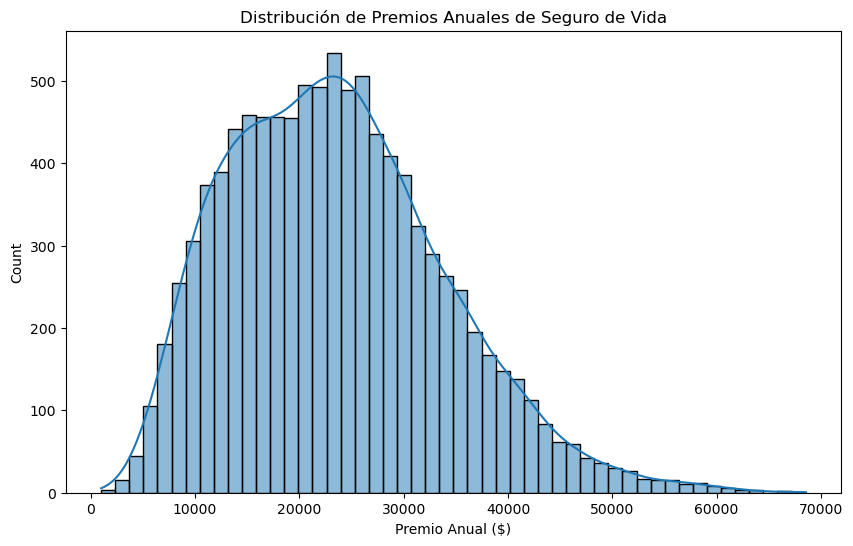

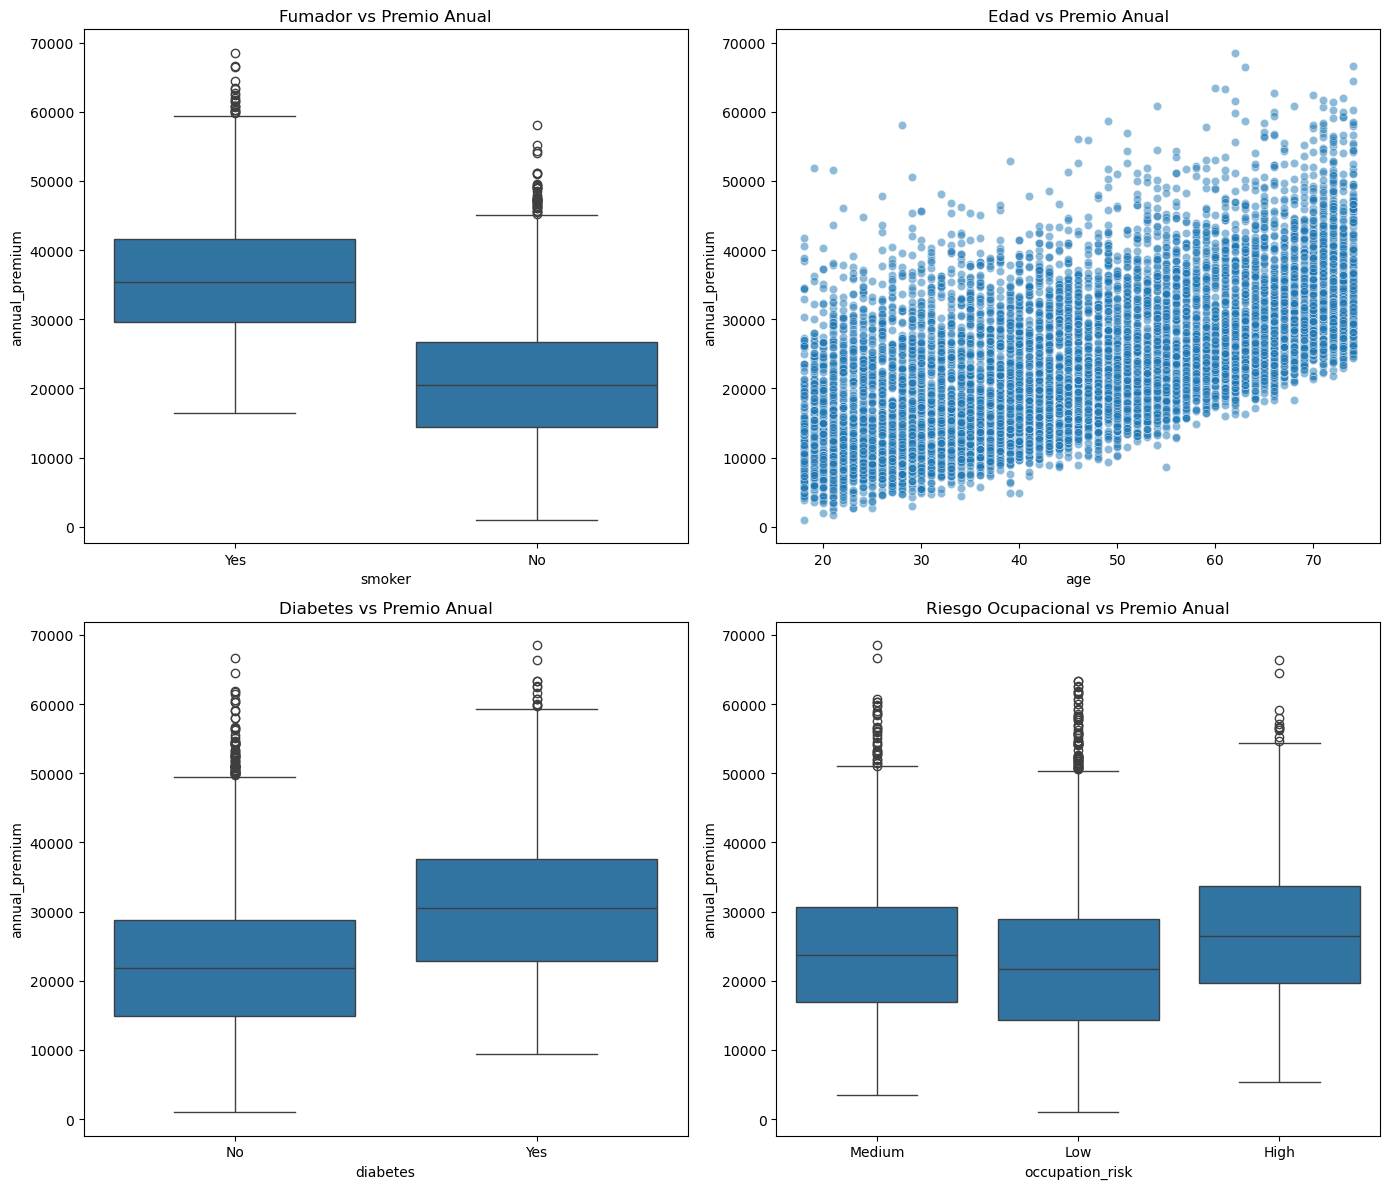


=== Ejemplos de clasificación de riesgo (primeros 10 casos) ===
      actual_premium  predicted_premium risk_level
6252         24188.0       21905.127396      Medio
4684         19945.0       25447.573595       Alto
1731         34781.0       38353.463235       Alto
4742         32711.0       30138.295490       Alto
4521         11907.0       12650.417587      Medio
6340         18529.0       20270.643777      Medio
576          38481.0       36082.079365       Alto
5202         18195.0       19188.295375      Medio
6363         26060.0       26732.640884       Alto
439          31157.0       37072.281250       Alto

Distribución de niveles de riesgo en test:
risk_level
Medio    55.6
Alto     44.4
Name: proportion, dtype: float64

Ejemplo de 'probabilidad aproximada' de alto riesgo (normalizada 0-1):
      predicted_premium  prob_high_risk risk_level
6252       21905.127396        0.223540      Medio
4684       25447.573595        0.295487       Alto
1731       38353.463235        0.

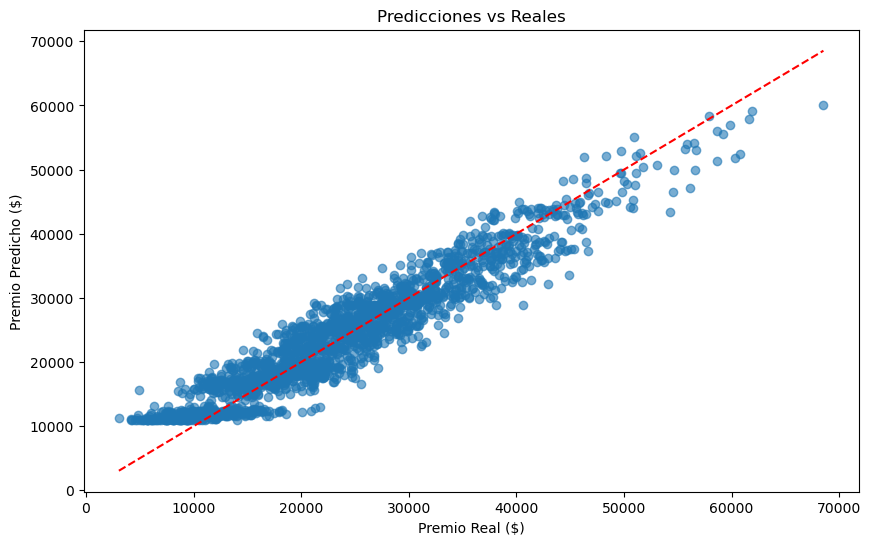

100%|██████████| 50/50 [03:04<00:00,  3.68s/it]


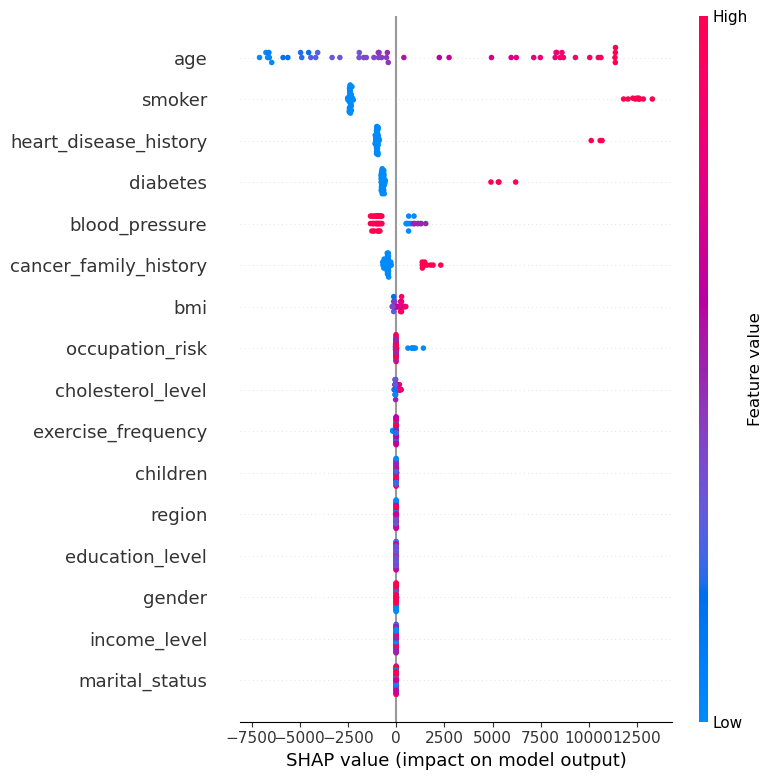

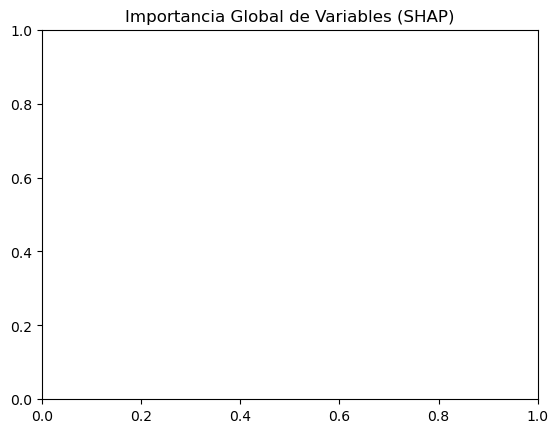

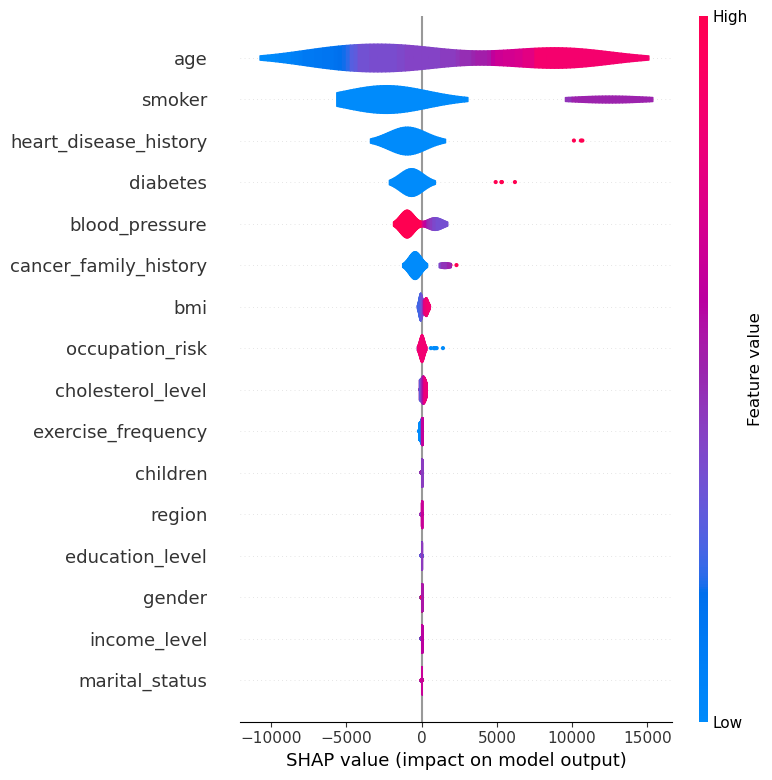

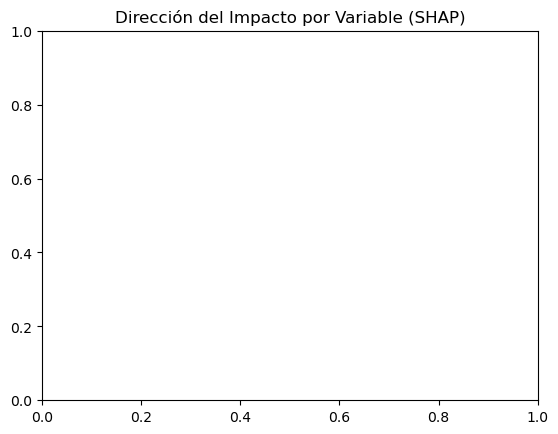

AttributeError: 'numpy.ndarray' object has no attribute 'index'

In [3]:
# =======================================================
# Ejemplo completo: Predicción de Premios/Costos de Seguros de Vida con AdaBoostRegressor
# Problema de REGRESIÓN: predecir 'annual_premium' (premio anual de seguro de vida en dólares)
# Dataset sintético profesional con 16 variables (demográficas + médicas) + target
# Incluye: Descripción de variables, EDA, entrenamiento, métricas, clasificación de riesgo (bajo/medio/alto),
# predicciones y análisis de sensibilidad con SHAP
# =======================================================
# Requisitos (instala si no los tienes):
# pip install pandas numpy scikit-learn matplotlib seaborn shap

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor  # Base estimator para AdaBoost
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import shap
import warnings
warnings.filterwarnings('ignore')

# =======================================================
# 1. Descripción detallada de las variables (significado profesional)
# =======================================================
# Creamos un DataFrame con el significado de cada variable para referencia clara
variable_descriptions = pd.DataFrame({
    'Variable': [
        'age', 'gender', 'bmi', 'children', 'occupation_risk', 
        'income_level', 'marital_status', 'education_level', 'region',
        'smoker', 'blood_pressure', 'cholesterol_level', 'diabetes',
        'heart_disease_history', 'cancer_family_history', 'exercise_frequency',
        'annual_premium'
    ],
    'Descripción': [
        'Edad del asegurado (años). Factor clave: mayores edades = mayor riesgo mortalidad → premios más altos.',
        'Género (Male/Female). Las mujeres suelen tener mayor esperanza de vida → premios ligeramente menores.',
        'Índice de masa corporal (BMI). BMI alto indica obesidad → mayor riesgo de enfermedades → premios altos.',
        'Número de hijos/dependientes. Puede influir en cobertura, pero indirectamente en riesgo.',
        'Nivel de riesgo ocupacional (Low/Medium/High). Ocupaciones peligrosas aumentan riesgo mortalidad.',
        'Nivel de ingresos (Low/Medium/High). Relacionado con capacidad de pago y estilo de vida.',
        'Estado civil (Single/Married/Divorced/Widowed). Casados suelen tener menor riesgo (estabilidad).',
        'Nivel educativo (High School/Bachelor/Master/PhD). Mayor educación correlaciona con mejor salud.',
        'Región geográfica (Northeast/Northwest/Southeast/Southwest). Diferencias en esperanza de vida por región.',
        'Fumador (Yes/No). Factor más fuerte: fumadores pagan 2-3x más por alto riesgo cáncer/pulmonar.',
        'Presión arterial (Normal/Elevated/High). Alta presión = mayor riesgo cardiovascular.',
        'Nivel de colesterol (mg/dL). Alto colesterol aumenta riesgo cardíaco.',
        'Diabetes (Yes/No). Enfermedad crónica que eleva significativamente el riesgo mortalidad.',
        'Historia de enfermedad cardíaca (Yes/No). Antecedentes familiares/personales = alto riesgo.',
        'Historia familiar de cáncer (Yes/No). Aumenta probabilidad de pólizas con exclusiones o premios altos.',
        'Frecuencia de ejercicio (None/Low/Medium/High). Mayor ejercicio = menor riesgo → premios menores.',
        'Premio anual del seguro de vida (target en dólares). Valor a predecir.'
    ],
    'Tipo': [
        'Numérica (int)', 'Categórica', 'Numérica (float)', 'Numérica (int)', 'Categórica ordinal',
        'Categórica ordinal', 'Categórica', 'Categórica ordinal', 'Categórica',
        'Binaria', 'Categórica ordinal', 'Numérica (int)', 'Binaria',
        'Binaria', 'Binaria', 'Categórica ordinal',
        'Numérica (float, target)'
    ]
})

print("=== Descripción detallada de las 17 variables (16 features + target 'annual_premium') ===")
print(variable_descriptions.to_string(index=False))

# =======================================================
# 2. Generación de dataset sintético profesional desde cero
# =======================================================
# Simulamos 10,000 asegurados con variables realistas para seguros de vida
# Premio anual generado con lógica actuarial (mayor riesgo = mayor premio)
np.random.seed(42)
n_samples = 10000

data = {
    # Demográficas
    'age': np.random.randint(18, 75, n_samples),  # Edad clave
    'gender': np.random.choice(['Male', 'Female'], n_samples, p=[0.52, 0.48]),
    'bmi': np.round(np.random.normal(27, 5, n_samples), 1).clip(16, 45),  # BMI realista
    'children': np.random.randint(0, 5, n_samples),
    'occupation_risk': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.6, 0.3, 0.1]),
    'income_level': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.4, 0.4, 0.2]),
    'marital_status': np.random.choice(['Single', 'Married', 'Divorced', 'Widowed'], n_samples),
    'education_level': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_samples, p=[0.4, 0.3, 0.2, 0.1]),
    'region': np.random.choice(['Northeast', 'Northwest', 'Southeast', 'Southwest'], n_samples),
    
    # Médicas
    'smoker': np.random.choice(['Yes', 'No'], n_samples, p=[0.18, 0.82]),  # ~18% fumadores
    'blood_pressure': np.random.choice(['Normal', 'Elevated', 'High'], n_samples, p=[0.55, 0.3, 0.15]),
    'cholesterol_level': np.round(np.random.normal(200, 45, n_samples)).clip(120, 350).astype(int),
    'diabetes': np.random.choice(['Yes', 'No'], n_samples, p=[0.12, 0.88]),
    'heart_disease_history': np.random.choice(['Yes', 'No'], n_samples, p=[0.08, 0.92]),
    'cancer_family_history': np.random.choice(['Yes', 'No'], n_samples, p=[0.25, 0.75]),
    'exercise_frequency': np.random.choice(['None', 'Low', 'Medium', 'High'], n_samples, p=[0.25, 0.35, 0.3, 0.1])
}

df = pd.DataFrame(data)

# Generar 'annual_premium' con lógica actuarial realista
base_premium = 500
age_effect = df['age'] ** 1.8 * 10  # Efecto exponencial con edad
smoker_effect = (df['smoker'] == 'Yes') * 15000  # Fumadores pagan mucho más
bmi_effect = np.maximum(0, df['bmi'] - 25) * 300
diabetes_effect = (df['diabetes'] == 'Yes') * 8000
heart_effect = (df['heart_disease_history'] == 'Yes') * 12000
blood_pressure_effect = (df['blood_pressure'] == 'High') * 6000 + (df['blood_pressure'] == 'Elevated') * 2500
cholesterol_effect = np.maximum(0, df['cholesterol_level'] - 200) * 40
occupation_effect = (df['occupation_risk'] == 'High') * 5000 + (df['occupation_risk'] == 'Medium') * 2000
exercise_effect = - (df['exercise_frequency'] == 'High') * 3000 - (df['exercise_frequency'] == 'Medium') * 1500  # Negativo = reducción
cancer_effect = (df['cancer_family_history'] == 'Yes') * 4000

noise = np.random.normal(0, 1500, n_samples)
df['annual_premium'] = np.round(base_premium + age_effect + smoker_effect + bmi_effect + diabetes_effect +
                                heart_effect + blood_pressure_effect + cholesterol_effect +
                                occupation_effect + exercise_effect + cancer_effect + noise).clip(1000)

print(f"\nDataset creado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"Rango de premios anuales: ${df['annual_premium'].min():,.0f} - ${df['annual_premium'].max():,.0f}")

# =======================================================
# 3. Exploratory Data Analysis (EDA)
# =======================================================
print("\n=== Descripción estadística general ===")
print(df.describe(include='all'))

# Distribución de premios
plt.figure(figsize=(10,6))
sns.histplot(df['annual_premium'], kde=True, bins=50)
plt.title('Distribución de Premios Anuales de Seguro de Vida')
plt.xlabel('Premio Anual ($)')
plt.show()

# Variables clave vs premio
fig, axes = plt.subplots(2, 2, figsize=(14,12))
sns.boxplot(x='smoker', y='annual_premium', data=df, ax=axes[0,0])
axes[0,0].set_title('Fumador vs Premio Anual')
sns.scatterplot(x='age', y='annual_premium', data=df, alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('Edad vs Premio Anual')
sns.boxplot(x='diabetes', y='annual_premium', data=df, ax=axes[1,0])
axes[1,0].set_title('Diabetes vs Premio Anual')
sns.boxplot(x='occupation_risk', y='annual_premium', data=df, ax=axes[1,1])
axes[1,1].set_title('Riesgo Ocupacional vs Premio Anual')
plt.tight_layout()
plt.show()

# =======================================================
# 4. Preprocesamiento
# =======================================================
# Codificar variables categóricas
cat_cols = df.select_dtypes(include='object').columns
le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Separar features y target
X = df.drop('annual_premium', axis=1)
y = df['annual_premium']

# Escalar (útil aunque AdaBoost es basado en árboles)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# =======================================================
# 5. Entrenamiento del modelo AdaBoostRegressor
# =======================================================
base_estimator = DecisionTreeRegressor(max_depth=5)
model = AdaBoostRegressor(
    estimator=base_estimator,  # Corregido: usa 'estimator' en lugar de 'base_estimator' (compatible con scikit-learn 1.2+)
    n_estimators=300,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

# =======================================================
# 6. Predicciones y clasificación de riesgo
# =======================================================
y_pred = model.predict(X_test)

# Clasificación de riesgo basada en premio predicho
# Bajo: < $10,000 | Medio: $10,000 - $25,000 | Alto: > $25,000 (ajustable a contexto actuarial)
def classify_risk(premium):
    if premium < 10000:
        return 'Bajo'
    elif premium < 25000:
        return 'Medio'
    else:
        return 'Alto'

df_test = pd.DataFrame({'actual_premium': y_test, 'predicted_premium': y_pred})
df_test['risk_level'] = df_test['predicted_premium'].apply(classify_risk)

print("\n=== Ejemplos de clasificación de riesgo (primeros 10 casos) ===")
print(df_test[['actual_premium', 'predicted_premium', 'risk_level']].head(10))

print("\nDistribución de niveles de riesgo en test:")
print(df_test['risk_level'].value_counts(normalize=True) * 100)

# No hay "probabilidades" directas en regresión, pero podemos interpretar confianza vía error residual
# Aquí aproximamos "probabilidad de alto riesgo" como normalización del premio predicho
df_test['prob_high_risk'] = (df_test['predicted_premium'] - df_test['predicted_premium'].min()) / \
                            (df_test['predicted_premium'].max() - df_test['predicted_premium'].min())

print("\nEjemplo de 'probabilidad aproximada' de alto riesgo (normalizada 0-1):")
print(df_test[['predicted_premium', 'prob_high_risk', 'risk_level']].head(10))

# =======================================================
# 7. Métricas de evaluación completas (regresión)
# =======================================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n=== Métricas del Modelo ===")
print(f"MAE: ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R²: {r2:.4f} (cuanto más cerca de 1, mejor)")

# Gráfico predicciones vs reales
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Premio Real ($)')
plt.ylabel('Premio Predicho ($)')
plt.title('Predicciones vs Reales')
plt.show()

# =======================================================
# 8. Análisis de sensibilidad con SHAP
# =======================================================
# Para AdaBoost, usamos KernelExplainer (model-agnostic) ya que TreeExplainer no soporta directamente AdaBoost
# Usamos subconjunto para velocidad (KernelExplainer es computacionalmente intensivo)
background = shap.kmeans(X_train, 100).data  # Fondo resumido con kmeans
explainer = shap.KernelExplainer(model.predict, background)

# SHAP values en subconjunto de test para demo
shap_test_subset = X_test[:50]
shap_values = explainer.shap_values(shap_test_subset)

# Importancia global
shap.summary_plot(shap_values, shap_test_subset, feature_names=X.columns)
plt.title('Importancia Global de Variables (SHAP)')
plt.show()

# Dirección del impacto
shap.summary_plot(shap_values, shap_test_subset, plot_type="violin", feature_names=X.columns)
plt.title('Dirección del Impacto por Variable (SHAP)')
plt.show()

# Ejemplo individual (caso de alto riesgo)
high_risk_idx = df_test[df_test['risk_level'] == 'Alto'].index[0]
local_idx = np.where(X_test.index == high_risk_idx)[0][0]
print(f"\nEjemplo individual (alto riesgo): Premio predicho ${df_test.loc[high_risk_idx, 'predicted_premium']:,.0f}")
shap.force_plot(explainer.expected_value, shap_values[local_idx], 
                shap_test_subset[local_idx], feature_names=X.columns, matplotlib=True)
plt.show()

print("\n¡Análisis completo terminado!")
print("Variables más influyentes: smoker, age, bmi, diabetes, occupation_risk, etc.")
print("AdaBoost captura bien interacciones complejas en datos de seguros de vida.")
print("Nota: SHAP usa KernelExplainer para AdaBoost; para muestras grandes, usa subconjuntos o hardware potente.")